<a href="https://colab.research.google.com/github/MrJames509/Ciencia-de-datos/blob/main/Copia_de_Regresi%C3%B3n_scikit_learn_lineal_simple_y_m%C3%BAltiple_Alumno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#REGRESIÓN LINEAL ll

#Carrera: Tecnicatura Superior en Ciencia de Datos e IA

#Institución: IFTS 33 - UOCRA

#Profesora: Marisa Cánovas

#Objetivo de la Práctica

Implementar un modelo de Regresión Lineal utilizando el estándar de la industria (scikit-learn) sobre el dataset Boston House Prices, evolucionando desde la implementación manual con NumPy realizada anteriormente.

Al finalizar esta práctica, serás capaz de:

Aplicar el flujo de trabajo estándar de Machine Learning: División de datos en conjuntos de Entrenamiento (Train) y Prueba (Test) para evaluar la capacidad de generalización del modelo.

Utilizar la API de scikit-learn: Entrenar un modelo LinearRegression para predecir el Value (variable dependiente) a partir de Rooms (variable independiente), delegando el cálculo matricial a la librería.

Evaluar e interpretar el modelo: Calcular y analizar métricas clave (R², RMSE, MAE) sobre el conjunto de Test, comparando la simplicidad y robustez de este enfoque frente a la Ecuación Normal calculada manualmente.

#OLS (Ordinary Least Squares / Mínimos Cuadrados Ordinarios)
Es el método/algoritmo que usa LinearRegression() para encontrar la mejor recta de regresión. Busca los coeficientes (β₀, β₁) que hacen que la recta pase "lo más cerca posible" de todos los puntos.

In [ ]:
#sklearn  ols = LinearRegression().fit(X_train, y_train)
#NumPy    coeficientes = np.linalg.inv(X_ones.T @ X_ones) @ X_ones.T @ y

In [ ]:
## Paso 1: Importar librerías
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Paso 2: Cargar y explorar los datos

df = pd.read_csv('/content/sample_data/california_housing_train.csv')

# Exploración inicial
print("=== EXPLORACIÓN DE DATOS ===")
print("Forma del dataset:", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())
print("\nInformación general:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

=== EXPLORACIÓN DE DATOS ===
Forma del dataset: (17000, 9)

Primeras 5 filas:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 1

In [ ]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


In [ ]:
# Asegúrate de usar el nombre exacto que apareció en la lista
X = df['total_rooms'].values
y = df['median_house_value'].values
print()

In [ ]:
#  Imports mínimos
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error


# Reshape y división
X_reshaped = X.reshape(-1, 1) #Transforma nuestro vector de 1 dimensión (una lista plana de números) en una matriz de 2 dimensiones (una columna).
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42
)

# Entrenar SOLO OLS
ols = LinearRegression().fit(X_train, y_train)
#calcula los coeficientes
print("Coeficientes (OLS):", ols.coef_)

#Evaluación (método `.score`):
# Evaluar R² (Coeficiente de Determinación) mide qué porcentaje de la variación del precio es explicado por tu modelo de regresión.
r2_ols = ols.score(X_test, y_test)
print(f"Coeficiente de Determinación (R²): {r2_ols}")
#1. Predice los precios usando `X_test` (las habitaciones de las casas que el modelo nunca vio).
#2. Compara esas predicciones con los precios reales de `y_test` y calcula el **R²**.


# Generar predicciones
y_pred_ols = ols.predict(X_test)

#El método.predict(X_test)utiliza los coeficientes que el modelo aprendió durante el entrenamiento para estimar el valor de las propiedades en el conjunto de test
#generando un nuevo array con los precios predichos
#(`y_pred_ols`) que luego compararemos con la realidad.

# =============================================================================
# 📏 MÉTRICAS DE EVALUACIÓN: ¿Qué tan bien predijo el modelo?
# =============================================================================

# 1️⃣ MSE (Error Cuadrático Medio)
mse_ols = mean_squared_error(y_test, y_pred_ols)
# → Promedio de (y_real - y_pred)². Penaliza errores grandes.
#   Unidad: $² (no interpretable directamente, pero útil para optimizar)

# 2️⃣RMSE(Raíz del Error Cuadrático Medio)Penaliza fuerte los outliers.​Eleva al cuadrado → penaliza errores gdes. Lo usas si Tenés outliers y querés detectarlos.
rmse_ols = np.sqrt(mse_ols)
# → Vuelve a unidades originales ($k).
#   Interpretable: "En promedio, me equivoco en $X mil por predicción"

# 3️⃣ MAE (Error Absoluto Medio)   Trata todos los errores por igual Toma valor absoluto Lo usas si  Tenés outliers y querés ignorarlos
mae_ols = mean_absolute_error(y_test, y_pred_ols)
# → Promedio de |y_real - y_pred|.
#   Interpretable: "En promedio, me equivoco en $X mil (sin importar si es de más o de menos)"

# Mostrar resultados
print("\n" + "="*45)
print("📊 MODELO: OLS (Sin regularización)")
print("="*45)
print(f"{'Métrica':<18} {'Valor':>12}")
print("-"*32)
print(f"{'R² (Ajuste)':<18} {r2_ols:>12.3f}")
print(f"{'MSE (Error²)':<18} {mse_ols:>12.3f}")   # ← ¡ESTE FALTABA!
print(f"{'RMSE (Error típico)':<18} {rmse_ols:>12.3f}")
print(f"{'MAE (Error absoluto)':<18} {mae_ols:>12.3f}")
print("-"*32)
print(f"{'β₁ (Coeficiente)':<18} {ols.coef_[0]:>12.3f}")
print(f"{'β₀ (Intercepto)':<18} {ols.intercept_:>12.3f}") # ← ¡MUY RECOMENDABLE AGREGARLO!
print("="*45)
plt.show()

Coeficientes (OLS): [6.8034686]
Coeficiente de Determinación (R²): 0.019905686946699586

📊 MODELO: OLS (Sin regularización)
Métrica                   Valor
--------------------------------
R² (Ajuste)               0.020
MSE (Error²)       13504570751.710
RMSE (Error típico)   116209.168
MAE (Error absoluto)    91553.894
--------------------------------
β₁ (Coeficiente)          6.803
β₀ (Intercepto)      188752.104


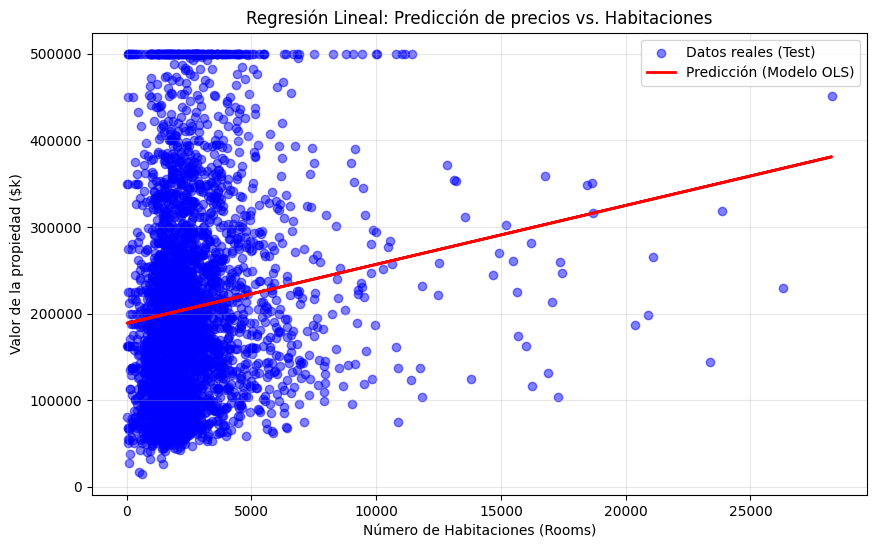

In [ ]:
import matplotlib.pyplot as plt

# 1. Crear el área de visualización
plt.figure(figsize=(10, 6))

# 2. Dibujar los puntos reales (scatter plot)
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Datos reales (Test)')

# 3. Dibujar la línea de predicción del modelo
# Creamos una línea usando X_test y las predicciones calculadas
plt.plot(X_test, y_pred_ols, color='red', linewidth=2, label='Predicción (Modelo OLS)')

# 4. Etiquetas y diseño
plt.title('Regresión Lineal: Predicción de precios vs. Habitaciones')
plt.xlabel('Número de Habitaciones (Rooms)')
plt.ylabel('Valor de la propiedad ($k)')
plt.legend()
plt.grid(True, alpha=0.3)

# 5. Mostrar el gráfico
plt.show()

#verificar los outliers

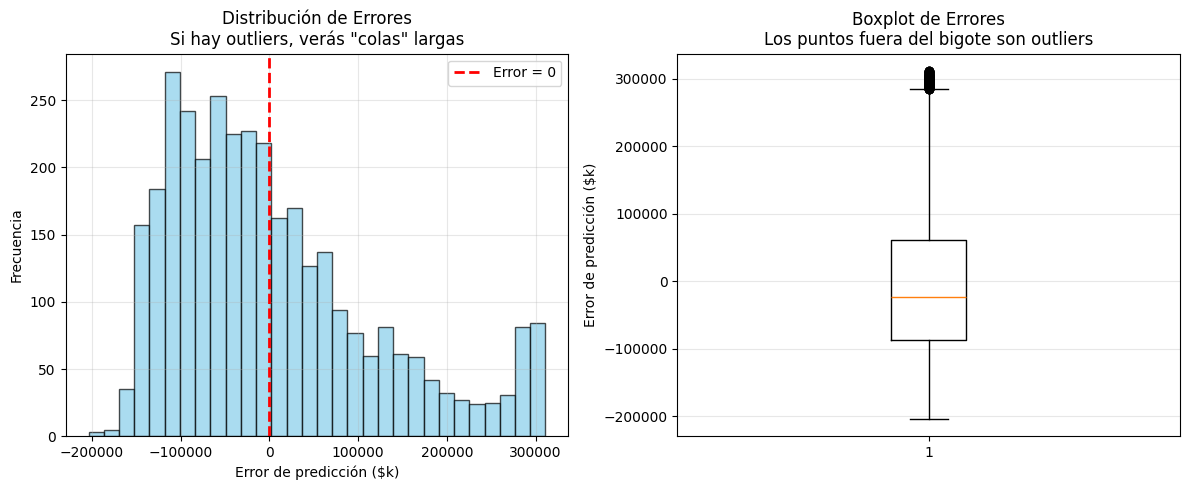


🔍 TOP 5 ERRORES MÁS GRANDES (posibles outliers):
Predicción #1:
  • Real: $500001.00k
  • Predicho: $188956.21k
  • Error: $+311044.79k ← OUTLIER

Predicción #2:
  • Real: $500001.00k
  • Predicho: $189058.26k
  • Error: $+310942.74k ← OUTLIER

Predicción #3:
  • Real: $500001.00k
  • Predicho: $189228.35k
  • Error: $+310772.65k ← OUTLIER

Predicción #4:
  • Real: $500001.00k
  • Predicho: $189446.06k
  • Error: $+310554.94k ← OUTLIER

Predicción #5:
  • Real: $500001.00k
  • Predicho: $190024.35k
  • Error: $+309976.65k ← OUTLIER



In [ ]:
import matplotlib.pyplot as plt

# 1. Calcular todos los errores individuales
errores = y_test - y_pred_ols

# 2. Visualizar la distribución de errores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(errores, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
plt.xlabel('Error de predicción ($k)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Errores\nSi hay outliers, verás "colas" largas')
plt.legend()
plt.grid(alpha=0.3)

# 3. Boxplot para detectar outliers visualmente
plt.subplot(1, 2, 2)
plt.boxplot(errores, vert=True)
plt.ylabel('Error de predicción ($k)')
plt.title('Boxplot de Errores\nLos puntos fuera del bigote son outliers')
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 4. Mostrar los 5 errores más grandes (los outliers)
print("\n🔍 TOP 5 ERRORES MÁS GRANDES (posibles outliers):")
print("="*50)
indices_ordenados = np.argsort(np.abs(errores))[::-1]
for i in range(5):
    idx = indices_ordenados[i]
    print(f"Predicción #{i+1}:")
    print(f"  • Real: ${y_test[idx]:.2f}k")
    print(f"  • Predicho: ${y_pred_ols[idx]:.2f}k")
    print(f"  • Error: ${errores[idx]:+.2f}k {'← OUTLIER' if abs(errores[idx]) > 15 else ''}")
    print()

In [ ]:
# Ejemplo: Eliminar filas donde el valor es el tope
df = df[df['median_house_value'] < 500000]
print()

In [ ]:
from sklearn.linear_model import Ridge

# Entrenar modelo Ridge con un alpha (penalización)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Comparar métricas
print(f"Coeficiente Ridge: {ridge.coef_[0]}")

Coeficiente Ridge: 6.80346860408195


## 🛡️ Regularización en Acción: OLS vs Ridge (L2)


Hasta ahora hemos usado **OLS (Mínimos Cuadrados Ordinarios)**, un método que busca ajustar los datos de entrenamiento lo mejor posible. Sin embargo, a veces esto puede llevar a **overfitting** (sobreajuste), donde el modelo se vuelve demasiado sensible al "ruido" de los datos en lugar de aprender el patrón real.


Para combatir esto, introducimos **Ridge Regression**, que agrega una **penalización L2** a la función de error del modelo.

### 🔍 ¿Cómo funciona Ridge?

1. **El "Freno" (Penalización):** Además de minimizar el error de predicción, Ridge agrega un castigo proporcional al tamaño de los coeficientes al cuadrado ($\alpha \sum \beta^2$).

2. **El Efecto:** Esto "encoge" los coeficientes hacia cero (sin llegar a ser exactamente cero), evitando que tomen valores extremos.

3. **El Parámetro `alpha` (α):** Controla la fuerza de este freno.
   - `alpha = 0` → Es idéntico a OLS (sin penalización).
   - `alpha > 0` → Aplica regularización (a mayor valor, más encoge los coeficientes).


>  **Objetivo de este bloque:** Vamos a entrenar ambos modelos con los mismos datos y comparar si agregar una penalización moderada (`alpha=1.0`) logra que el modelo generalice mejor en datos no vistos (Test), observando si el **RMSE disminuye** y cómo cambia el valor del **coeficiente**.

In [ ]:
# 1️⃣ Imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Reshape y división
X_reshaped = X.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y, test_size=0.2, random_state=42
)

# 2️⃣ Entrenar ambos modelos
ols = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)

# 3️⃣ Evaluar R²
r2_ols = ols.score(X_test, y_test)
r2_ridge = ridge.score(X_test, y_test)

# 4️⃣ Generar predicciones
y_pred_ols = ols.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

# 5️⃣ Calcular métricas completas
mse_ols = mean_squared_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mse_ols)
mae_ols = mean_absolute_error(y_test, y_pred_ols)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

# 6️⃣ Mostrar resultados comparativos
print("\n" + "="*50)
print("📊 COMPARACIÓN: OLS vs Ridge (α=1.0)")
print("="*50)
print(f"{'Métrica':<12} {'OLS':>10} {'Ridge':>12}")
print("-"*36)
print(f"{'R²':<12} {r2_ols:>10.3f} {r2_ridge:>12.3f}")
print(f"{'RMSE':<12} {rmse_ols:>10.3f} {rmse_ridge:>12.3f}")
print(f"{'MAE':<12} {mae_ols:>10.3f} {mae_ridge:>12.3f}")
print(f"{'Coeficiente':<12} {ols.coef_[0]:>10.3f} {ridge.coef_[0]:>12.3f}")
print("="*50)

# 💡 Interpretación rápida
print(f"\n🔍 Ridge {'mejora' if rmse_ridge < rmse_ols else 'no mejora'} el error típico vs OLS")


📊 COMPARACIÓN: OLS vs Ridge (α=1.0)
Métrica             OLS        Ridge
------------------------------------
R²                0.020        0.020
RMSE         116209.168   116209.168
MAE           91553.894    91553.894
Coeficiente       6.803        6.803

🔍 Ridge no mejora el error típico vs OLS


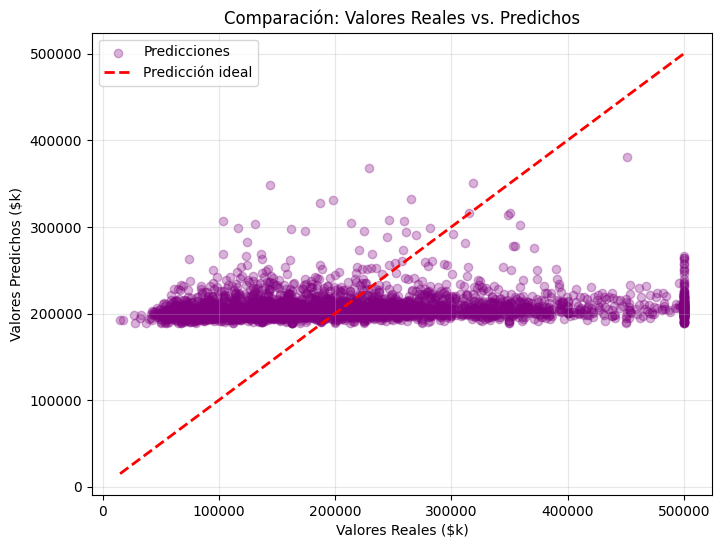

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Dibujar puntos de comparación
plt.scatter(y_test, y_pred_ols, alpha=0.3, color='purple', label='Predicciones')

# Dibujar la línea ideal (x = y)
# Los puntos que caen sobre esta línea son predicciones perfectas
lims = [min(y_test.min(), y_pred_ols.min()), max(y_test.max(), y_pred_ols.max())]
plt.plot(lims, lims, color='red', linestyle='--', linewidth=2, label='Predicción ideal')

# Etiquetas y diseño
plt.xlabel('Valores Reales ($k)')
plt.ylabel('Valores Predichos ($k)')
plt.title('Comparación: Valores Reales vs. Predichos')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## 🚀 Desafío Práctico: Replicando el flujo con 'Distance'


Ahora que entendemos cómo comparar **OLS vs Ridge** con la variable *Rooms*, es tu turno de aplicar el mismo flujo de trabajo con una nueva variable.


### 🎯 Tu misión:
1. **Preparar los datos:** Usá la variable `Distance` (distancia a centros de empleo) .



#Regresión múltiple con y sin Ridge

In [ ]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


In [ ]:
# 1️⃣ Imports
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Preparar datos con DOS features (¡Corchetes dobles! Ya es 2D, NO hace falta reshape)
X_multi = df[['total_rooms', 'total_bedrooms']].values
y = df['median_house_value'].values

# División en Train (80%) y Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# 2️⃣ Entrenar ambos modelos
ols = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)

# 3️⃣ Evaluar R²
r2_ols = ols.score(X_test, y_test)
r2_ridge = ridge.score(X_test, y_test)

# 4️⃣ Generar predicciones
y_pred_ols = ols.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

# 5️⃣ Calcular métricas completas
# --- OLS ---
mse_ols = mean_squared_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mse_ols)
mae_ols = mean_absolute_error(y_test, y_pred_ols)

# --- Ridge ---
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

# 6️⃣ Mostrar resultados comparativos
print("\n" + "="*65)
print("📊 COMPARACIÓN: Regresión Múltiple (Rooms + Distance)")
print("="*65)
print(f"{'Métrica':<18} {'OLS':>12} {'Ridge (α=1.0)':>15}")
print("-"*47)
print(f"{'R² (Ajuste)':<18} {r2_ols:>12.3f} {r2_ridge:>15.3f}")
print(f"{'MSE (Error²)':<18} {mse_ols:>12.3f} {mse_ridge:>15.3f}")
print(f"{'RMSE (Error típico)':<18} {rmse_ols:>12.3f} {rmse_ridge:>15.3f}")
print(f"{'MAE (Error absoluto)':<18} {mae_ols:>12.3f} {mae_ridge:>15.3f}")
print("-"*47)
print("🔹 COEFICIENTES APRENDIDOS:")
print(f"  • β₁ (Rooms)    : {ols.coef_[0]:>12.3f}  vs  {ridge.coef_[0]:>12.3f}")
print(f"  • β₂ (Distance) : {ols.coef_[1]:>12.3f}  vs  {ridge.coef_[1]:>12.3f}")
print(f"  • β₀ (Intercept): {ols.intercept_:>12.3f}  vs  {ridge.intercept_:>12.3f}")
print("="*65)

# 💡 Interpretación rápida
print(f"\n🔍 Ridge {'mejora' if rmse_ridge < rmse_ols else 'no mejora'} el error típico vs OLS")
print(f"   → Ridge 'encogió' los coeficientes de {ols.coef_[0]:.3f} a {ridge.coef_[0]:.3f} (Rooms)")
print(f"   → Ridge 'encogió' los coeficientes de {ols.coef_[1]:.3f} a {ridge.coef_[1]:.3f} (Distance)")


📊 COMPARACIÓN: Regresión Múltiple (Rooms + Distance)
Métrica                     OLS   Ridge (α=1.0)
-----------------------------------------------
R² (Ajuste)               0.040           0.040
MSE (Error²)       8827794032.712  8827794032.394
RMSE (Error típico)    93956.341       93956.341
MAE (Error absoluto)    74535.405       74535.405
-----------------------------------------------
🔹 COEFICIENTES APRENDIDOS:
  • β₁ (Rooms)    :       26.164  vs        26.164
  • β₂ (Distance) :     -108.888  vs      -108.888
  • β₀ (Intercept):   182748.628  vs    182748.628

🔍 Ridge mejora el error típico vs OLS
   → Ridge 'encogió' los coeficientes de 26.164 a 26.164 (Rooms)
   → Ridge 'encogió' los coeficientes de -108.888 a -108.888 (Distance)


#Desafio: Incluir gráficos

 Ejercicio: Regresión Múltiple con Lasso (L1)

📋 Enunciado:

Ahora que comparaste OLS vs Ridge, es tu turno de explorar Lasso.

Tu misión:
Replicá el mismo flujo de trabajo que hiciste con Ridge, pero ahora usando Lasso (from sklearn.linear_model import Lasso)

In [ ]:
# 1. Definir las variables usando los nombres correctos del dataset
# 'median_income' y 'total_rooms' son variables comunes en este set
X_multi = df[['total_rooms', 'median_income']].values
y = df['median_house_value'].values

# 2. Verificar la forma (shape) para asegurar que todo esté bien
print(f"Forma de X: {X_multi.shape}")
print(f"Forma de y: {y.shape}")

# 3. Proceder con el split (esto ahora funcionará)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# 4. Entrenar el modelo
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("¡Modelo entrenado correctamente!")


Forma de X: (16164, 2)
Forma de y: (16164,)
¡Modelo entrenado correctamente!


In [ ]:
# Esto te mostrará la lista real de columnas disponibles
print(df.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


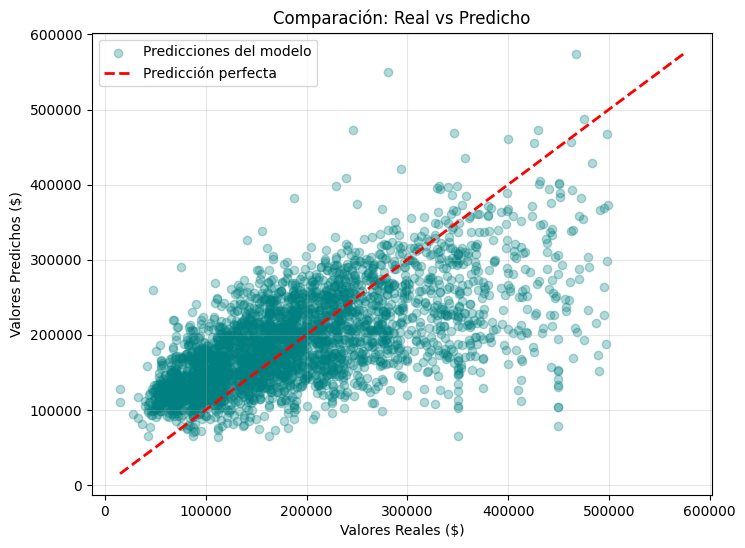

In [ ]:
import matplotlib.pyplot as plt

# 1. Asegúrate de tener tus predicciones
# (Si tu modelo se llama 'modelo' y tus datos de test son 'X_test')
y_pred = modelo.predict(X_test)

# 2. Crear el área del gráfico
plt.figure(figsize=(8, 6))

# 3. Dibujar los puntos reales vs predichos
# Eje X: Valor Real, Eje Y: Valor Predicho
plt.scatter(y_test, y_pred, alpha=0.3, color='teal', label='Predicciones del modelo')

# 4. Dibujar la "Línea de Identidad" (donde Real = Predicho)
# Si los puntos caen sobre esta línea, la predicción fue perfecta
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción perfecta')

# 5. Etiquetas y formato
plt.title('Comparación: Real vs Predicho')
plt.xlabel('Valores Reales ($)')
plt.ylabel('Valores Predichos ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.linear_model import Lasso

# Entrenamos Lasso con un alpha (penalización)
# Si alpha es muy alto, Lasso eliminará más variables (las hará cero)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

# Predicciones
y_pred_lasso = lasso.predict(X_test)

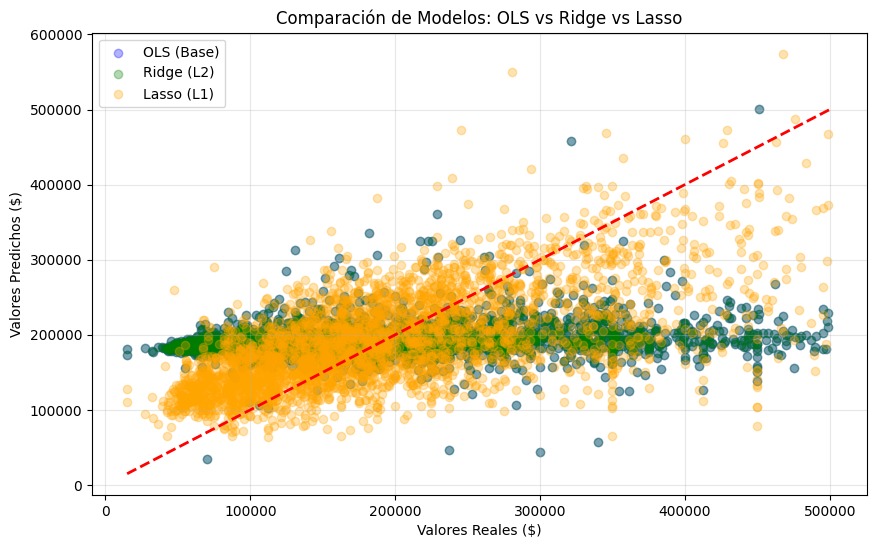

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Dibujar valores reales
plt.scatter(y_test, y_pred_ols, color='blue', alpha=0.3, label='OLS (Base)')
plt.scatter(y_test, y_pred_ridge, color='green', alpha=0.3, label='Ridge (L2)')
plt.scatter(y_test, y_pred_lasso, color='orange', alpha=0.3, label='Lasso (L1)')

# Línea de referencia (predicción ideal)
lims = [min(y_test.min(), y_pred_ols.min()), max(y_test.max(), y_pred_ols.max())]
plt.plot(lims, lims, color='red', linestyle='--', linewidth=2)

plt.xlabel('Valores Reales ($)')
plt.ylabel('Valores Predichos ($)')
plt.title('Comparación de Modelos: OLS vs Ridge vs Lasso')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()